# PEEC solver benchmarks: dense Ruehli vs HACApK

This notebook is the human-facing layer for the PEEC solver benchmark corpus. It reads the committed benchmark JSON in this directory, renders tables and figures with saved outputs, and writes a synchronized JSON sidecar for future debugging.

Executable benchmark drivers live in `validation_test/solver_benchmarks/`. They refresh the raw `results_bench_peec_*.json` files here; after refreshing those files, rerun this notebook so the rendered notebook and sidecar stay in sync.


## Method

The dense baseline assembles the Ruehli partial-inductance matrix directly and solves the single-frequency PEEC system with dense linear algebra. The HACApK path stores the same mutual-inductance operator as an H-matrix and applies it through the PEEC Krylov solver.

For the full nodal MNA benchmark, the maintained HACApK path uses the saddle-point formulation in `PEECCircuitSolver(outer_method="saddle")`. The important public claims are kept deliberately narrow: the benchmark records memory reduction, solve-time crossover, convergence status, and the measured `|Z11|` values without relying on an `examples/` path.


In [1]:

from __future__ import annotations

import datetime as dt
import hashlib
import importlib.metadata as im
import json
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

DOCS_DIR = Path.cwd()
REPO_ROOT = DOCS_DIR.parents[1]
VALIDATION_DIR = REPO_ROOT / "validation_test" / "solver_benchmarks"
RESULTS_JSON = DOCS_DIR / "peec_solver_benchmarks_results.json"
RAW_JSON_FILES = {
    "dense": DOCS_DIR / "results_bench_peec_dense.json",
    "hacapk": DOCS_DIR / "results_bench_peec_hacapk.json",
    "mna_crossover": DOCS_DIR / "results_bench_peec_mna_crossover.json",
}
SOURCE_FILES = [
    VALIDATION_DIR / "bench_peec_dense.py",
    VALIDATION_DIR / "bench_peec_hacapk.py",
    VALIDATION_DIR / "bench_peec_mna_crossover.py",
    VALIDATION_DIR / "validate_peec_circuit_hacapk.py",
    DOCS_DIR / "compare_peec_dense_vs_hacapk.py",
    DOCS_DIR / "findings_peec_mna_crossover.md",
    DOCS_DIR / "comparison_peec_dense_vs_hacapk.md",
    DOCS_DIR / "comparison_peec_dense_vs_hacapk.tex",
]

def sha256_bytes(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()

def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

raw = {name: read_json(path) for name, path in RAW_JSON_FILES.items()}
dense = raw["dense"]["results"]
hacapk = raw["hacapk"]["results"]
cross = raw["mna_crossover"]["results"]

versions = {
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy_version": np.__version__,
}
for pkg in ["radia", "radia-mcp", "matplotlib"]:
    try:
        versions[pkg.replace("-", "_") + "_version"] = im.version(pkg)
    except Exception:
        versions[pkg.replace("-", "_") + "_version"] = None

json_rows = [
    f"| {name} | `{path.name}` | {len(raw[name]['results'])} | `{sha256_bytes(path)[:12]}` | {raw[name].get('timestamp', '')} |"
    for name, path in RAW_JSON_FILES.items()
]
display(Markdown("\n".join([
    "### Benchmark JSON inventory",
    "",
    "| corpus | file | rows | sha256 prefix | measured at |",
    "|---|---:|---:|---|---|",
    *json_rows,
])))

assert dense, "dense benchmark JSON has no rows"
assert hacapk, "HACApK benchmark JSON has no rows"
assert cross, "MNA crossover benchmark JSON has no rows"
assert all(Path(p).exists() for p in RAW_JSON_FILES.values())


### Benchmark JSON inventory

| corpus | file | rows | sha256 prefix | measured at |
|---|---:|---:|---|---|
| dense | `results_bench_peec_dense.json` | 5 | `1b815aa4354f` | 2026-04-16T07:31:56.252091 |
| hacapk | `results_bench_peec_hacapk.json` | 7 | `5d4ed89482f0` | 2026-04-16T14:50:08.733719 |
| mna_crossover | `results_bench_peec_mna_crossover.json` | 10 | `780e2163fef9` | 2026-04-17T08:47:54.866433 |

### Partial-inductance benchmark

| n_fil | dense L MB | H-mat MB | compression | dense solve s | HACApK solve s | |Z11| dense | |Z11| HACApK |
|---|---|---|---|---|---|---|---|
| 500 | 1.9 | 1.9 | 1.000 | 0.0675 | 0.00308 | 1.47 | 1.41 |
| 2000 | 30.5 | 27.5 | 0.900 | 1.65 | 0.235 | 1.46 | 5.35 |
| 4500 | 154.5 | 77.2 | 0.500 | 16.1 | 0.843 | 1.46 | 12.2 |
| 8000 | 488.3 | 64.1 | 0.131 | 83.9 | 1.09 | 1.46 | 20.3 |
| 12500 | 1192.1 | 79.6 | 0.067 | 349 | 1.37 | 1.46 | 31.9 |
| 18000 | 2471.9 | 89.5 | 0.036 | -- | 1.77 | -- | 45 |
| 24500 | 4579.5 | 156.8 | 0.034 | -- | 3.05 | -- | 61.3 |

### MNA dense vs HACApK crossover

| n_fil | dense total s | HACApK total s | dense/HACApK | HACApK peak MB |
|---|---|---|---|---|
| 200 | 0.00952 | 0.0353 | 0.27x | 110.6 |
| 800 | 0.122 | 0.278 | 0.44x | 122.4 |
| 1800 | 1.09 | 3.04 | 0.36x | 157.5 |
| 3200 | 5.63 | 4.77 | 1.18x | 264.6 |
| 5000 | 20.6 | 13.6 | 1.52x | 489.9 |

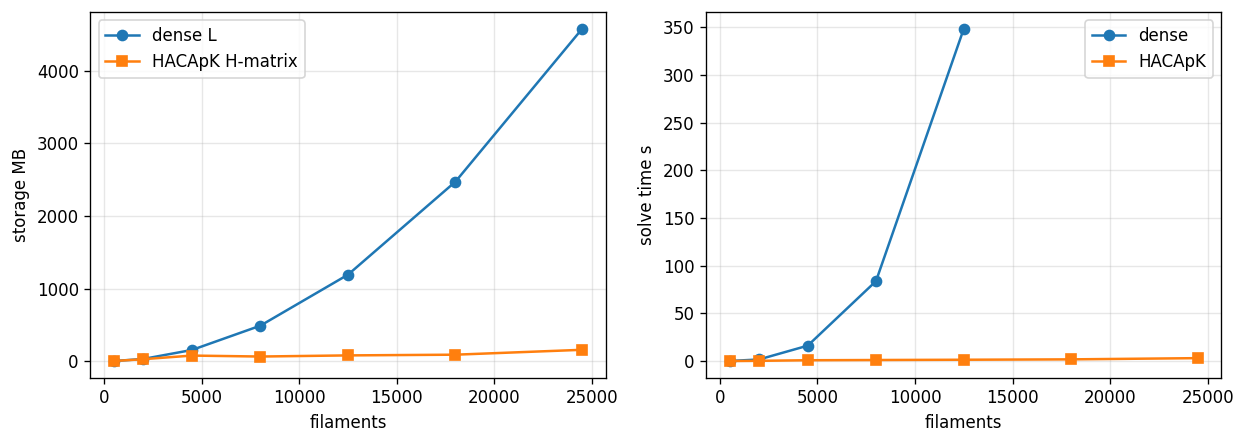

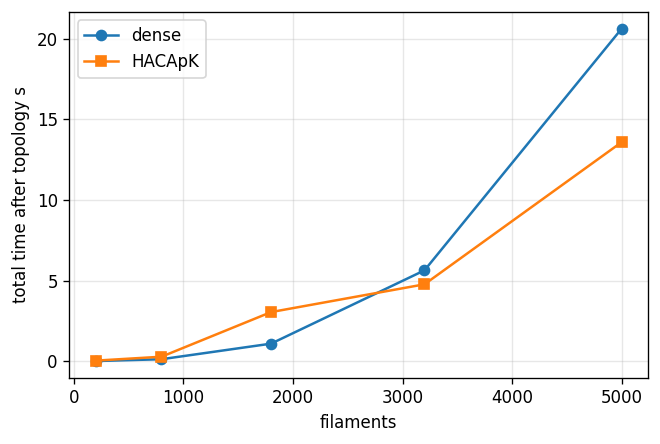

In [2]:

def md_table(headers, rows):
    out = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    out.extend("| " + " | ".join(str(c) for c in row) + " |" for row in rows)
    return "\n".join(out)

def fmt_s(x):
    if x is None:
        return "--"
    return f"{x:.3g}"

def fmt_mb(x):
    if x is None:
        return "--"
    return f"{x:.1f}"

dmap = {int(d["n_fil"]): d for d in dense}
hrows = []
for h in hacapk:
    n = int(h["n_fil"])
    d = dmap.get(n)
    hrows.append([
        n,
        fmt_mb(h.get("dense_L_mb")),
        fmt_mb(h.get("hmatrix_mb")),
        f"{h.get('compression', float('nan')):.3f}",
        fmt_s(d.get("t_solve") if d else None),
        fmt_s(h.get("t_solve")),
        fmt_s(d.get("abs_Z11") if d else None),
        fmt_s(h.get("abs_Z11")),
    ])

display(Markdown("\n".join([
    "### Partial-inductance benchmark",
    "",
    md_table(
        ["n_fil", "dense L MB", "H-mat MB", "compression", "dense solve s", "HACApK solve s", "|Z11| dense", "|Z11| HACApK"],
        hrows,
    ),
])))

cd = [c for c in cross if c.get("mode") == "dense"]
ch = [c for c in cross if c.get("mode") == "hacapk"]
cd_by_n = {int(c["n_fil"]): c for c in cd}
ch_by_n = {int(c["n_fil"]): c for c in ch}
common = sorted(set(cd_by_n) & set(ch_by_n))
cross_rows = []
for n in common:
    td = cd_by_n[n]["t_total_after_topology"]
    th = ch_by_n[n]["t_total_after_topology"]
    cross_rows.append([n, f"{td:.3g}", f"{th:.3g}", f"{td / th:.2f}x", f"{ch_by_n[n]['peak_memory_mb']:.1f}"])

display(Markdown("\n".join([
    "### MNA dense vs HACApK crossover",
    "",
    md_table(["n_fil", "dense total s", "HACApK total s", "dense/HACApK", "HACApK peak MB"], cross_rows),
])))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), dpi=120)
nh = [int(h["n_fil"]) for h in hacapk]
axes[0].plot(nh, [h.get("dense_L_mb", np.nan) for h in hacapk], "o-", label="dense L")
axes[0].plot(nh, [h["hmatrix_mb"] for h in hacapk], "s-", label="HACApK H-matrix")
axes[0].set_xlabel("filaments")
axes[0].set_ylabel("storage MB")
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].plot([d["n_fil"] for d in dense], [d["t_solve"] for d in dense], "o-", label="dense")
axes[1].plot(nh, [h["t_solve"] for h in hacapk], "s-", label="HACApK")
axes[1].set_xlabel("filaments")
axes[1].set_ylabel("solve time s")
axes[1].grid(alpha=0.3)
axes[1].legend()
plt.tight_layout()
display(fig)
plt.close(fig)

fig2, ax = plt.subplots(figsize=(5.6, 3.8), dpi=120)
ax.plot([c["n_fil"] for c in cd], [c["t_total_after_topology"] for c in cd], "o-", label="dense")
ax.plot([c["n_fil"] for c in ch], [c["t_total_after_topology"] for c in ch], "s-", label="HACApK")
ax.set_xlabel("filaments")
ax.set_ylabel("total time after topology s")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
display(fig2)
plt.close(fig2)

best_common = max(common)
assert cd_by_n[best_common]["t_total_after_topology"] / ch_by_n[best_common]["t_total_after_topology"] > 1.0
assert all(h.get("converged") for h in hacapk), "HACApK partial-inductance rows must converge"
assert all(c.get("converged") for c in cross), "MNA crossover rows must converge"


In [3]:

source_records = []
for path in SOURCE_FILES:
    text = path.read_text(encoding="utf-8")
    source_records.append({
        "path": str(path.relative_to(REPO_ROOT)).replace("\\", "/"),
        "sha256": hashlib.sha256(text.encode("utf-8")).hexdigest(),
        "chars": len(text),
        "source_text": text,
    })

summary = {
    "dense_rows": len(dense),
    "hacapk_rows": len(hacapk),
    "mna_rows": len(cross),
    "max_hacapk_filaments": max(int(h["n_fil"]) for h in hacapk),
    "mna_common_filaments": common,
    "mna_largest_common_speedup_dense_over_hacapk": cd_by_n[best_common]["t_total_after_topology"] / ch_by_n[best_common]["t_total_after_topology"],
    "mna_largest_common_hacapk_peak_memory_mb": ch_by_n[best_common]["peak_memory_mb"],
    "raw_json_sha256": {
        name: sha256_bytes(path) for name, path in RAW_JSON_FILES.items()
    },
}

payload = {
    "schema": "radia.docs.solver_benchmarks.v1",
    "generated_at_utc": dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds").replace("+00:00", "Z"),
    "versions": versions,
    "notebook": "docs/solver_benchmarks/peec_solver_benchmarks.ipynb",
    "policy": {
        "result_saved_ipynb": True,
        "synchronized_json": True,
        "raw_results_in_docs": True,
        "executable_drivers": "validation_test/solver_benchmarks/",
    },
    "summary": summary,
    "raw_benchmark_payloads": raw,
    "source_files": source_records,
}
RESULTS_JSON.write_text(json.dumps(payload, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
display(Markdown(f"Wrote `{RESULTS_JSON.name}` with {len(source_records)} source records and {len(raw)} benchmark payloads."))


Wrote `peec_solver_benchmarks_results.json` with 8 source records and 3 benchmark payloads.